# Real-data experiment 1: Chicago community-area compositions

This notebook reproduces the primary application in *Spatial
Autocorrelation for Manifold-Valued Geographic Data*. Five mutually
exclusive race and ethnicity counts are mapped to the positive orthant
of the unit sphere by the square-root
transformation. The intrinsic analysis is compared with chordal,
raw-share, Shannon-diversity, standardized multivariate, and
componentwise Euclidean baselines.

The unit of analysis is the official community area, not a census
tract. `PAPER_SCALE=True` reproduces the manuscript's 1,999 global and
999 local permutations; set it to `False` for 499 of each.

In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "autocorr.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autocorr as ac

ac.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = True
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")

Public root located. PAPER_SCALE=True


In [2]:
from matplotlib.patches import Patch

SEED = 20260719
global_permutations = 1999 if PAPER_SCALE else 499
local_permutations = 999 if PAPER_SCALE else 499
geography, composition, shares, W = ac.load_chicago()
component_names = ["White non-Hispanic", "Hispanic/Latino", "Black non-Hispanic",
                   "Asian non-Hispanic", "Other/multiple non-Hispanic"]

assert len(geography) == 77
assert np.allclose(shares.sum(axis=1), 1.0)
print(f"Loaded {len(geography)} community areas and {int(W.sum() / 2)} undirected queen links.")
print(f"Structural-zero areas: {int((shares == 0).any(axis=1).sum())}")
display(composition.head())

Loaded 77 community areas and 199 undirected queen links.
Structural-zero areas: 3


,area_num,community,white_nh,hispanic,black_nh,asian_nh,other_multiple_nh,category_total
0,1,Rogers Park,24150,12245,11729,3389,2660,54173
1,2,West Ridge,30859,16129,9180,17104,5101,78373
2,3,Uptown,29284,7971,10713,5831,2545,56344
3,4,Lincoln Square,25958,7405,1732,3814,2742,41651
4,5,North Center,26413,4267,846,2239,2249,36014


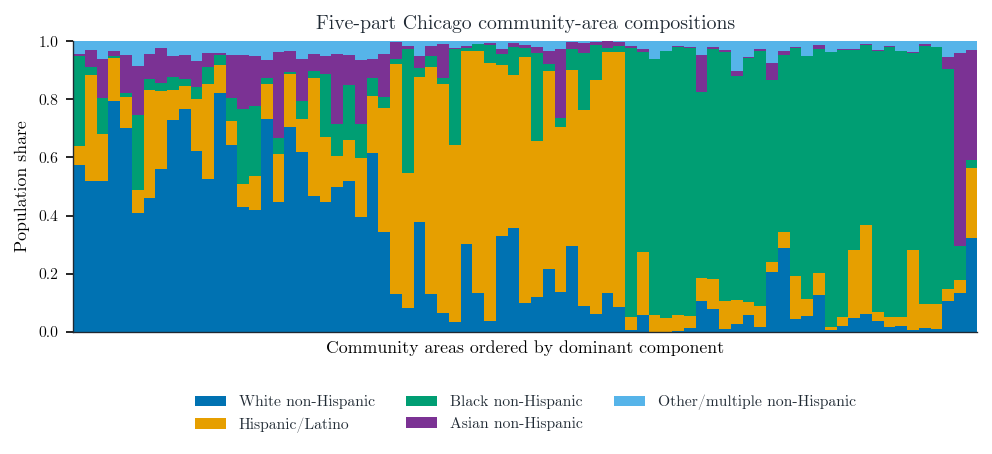

In [3]:
order = np.lexsort((composition["community"].to_numpy(), np.argmax(shares, axis=1)))
colors = [ac.BLUE, ac.GOLD, ac.GREEN, ac.PURPLE, ac.SKY]
fig, ax = plt.subplots(figsize=(ac.TEXT_WIDTH_IN, 2.9), constrained_layout=True)
bottom = np.zeros(len(shares))
for index, (name, color) in enumerate(zip(component_names, colors)):
    ax.bar(np.arange(len(shares)), shares[order, index], bottom=bottom,
           width=1.0, color=color, edgecolor="none", label=name)
    bottom += shares[order, index]
ax.set(xlabel="Community areas ordered by dominant component",
       ylabel="Population share", ylim=(0, 1), xlim=(-0.5, len(shares) - 0.5),
       title="Five-part Chicago community-area compositions")
ax.set_xticks([])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.17))
plt.show()

**Figure 1.** Five-part composition profiles ordered by their dominant
component. Areas with similar diversity can still have different
compositional directions.

In [4]:
sphere = np.sqrt(shares)
_, sphere_log, sphere_d2, sphere_v = ac.sphere_components(sphere)
methods = {
    "Intrinsic sphere": (sphere_log, sphere_d2, sphere_v),
    "Square-root chordal": ac.euclidean_components(sphere),
    "Raw shares": ac.euclidean_components(shares),
    "Shannon diversity": ac.scalar_components(
        -(shares * np.log(np.clip(shares, 1e-15, 1.0))).sum(axis=1) / np.log(shares.shape[1])
    ),
}
standardized = (shares - shares.mean(axis=0)) / shares.std(axis=0, ddof=0)
methods["Standardized shares"] = ac.euclidean_components(standardized)

global_rows = []
local_results = {}
for index, (name, (logarithms, distance_squared, dispersion)) in enumerate(methods.items()):
    global_result = ac.global_randomization(
        logarithms, distance_squared, W, V_mu=dispersion,
        permutations=global_permutations, seed=SEED + 500 + index,
    )
    local_result = ac.local_diagnostics(
        logarithms, distance_squared, W,
        permutations=local_permutations, seed=SEED + 600 + index,
    )
    local_results[name] = local_result
    global_rows.append({
        "method": name, **global_result.__dict__,
        "local Moran": int(local_result["I_significant"].sum()),
        "local Geary": int(local_result["G_significant"].sum()),
    })

for index, name in enumerate(component_names):
    logarithms, distance_squared, dispersion = ac.scalar_components(shares[:, index])
    result = ac.global_randomization(
        logarithms, distance_squared, W, V_mu=dispersion,
        permutations=global_permutations, seed=SEED + 700 + index,
    )
    global_rows.append({"method": name, **result.__dict__, "local Moran": np.nan, "local Geary": np.nan})

global_table = pd.DataFrame(global_rows)
display(global_table[["method", "I", "p_I_upper", "C_P", "p_CP_lower", "local Moran", "local Geary"]].round(4))

,method,I,p_I_upper,C_P,p_CP_lower,local Moran,local Geary
0,Intrinsic sphere,0.7074,0.0005,0.3017,0.0005,54.0,55.0
1,Square-root chordal,0.6990,0.0005,0.3145,0.0005,56.0,56.0
2,Raw shares,0.6976,0.0005,0.3202,0.0005,47.0,46.0
3,Shannon diversity,0.4607,0.0005,0.5327,0.0005,16.0,7.0
4,Standardized shares,0.5772,0.0005,0.4312,0.0005,55.0,53.0
5,White non-Hispanic,0.6730,0.0005,0.2722,0.0005,NaN,NaN
6,Hispanic/Latino,0.6712,0.0005,0.3761,0.0005,NaN,NaN
7,Black non-Hispanic,0.7540,0.0005,0.2819,0.0005,NaN,NaN
8,Asian non-Hispanic,0.3305,0.0005,0.6882,0.0260,NaN,NaN
9,Other/multiple non-Hispanic,0.4575,0.0005,0.5379,0.0005,NaN,NaN


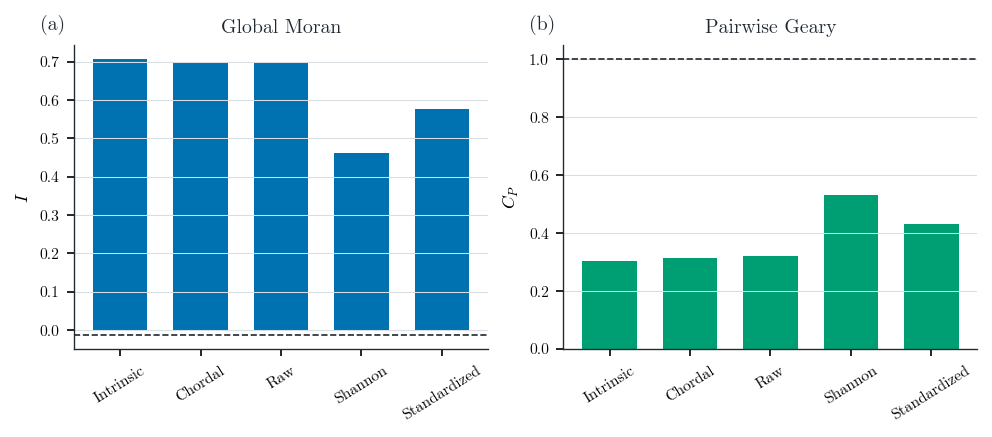

In [5]:
comparison = global_table.iloc[:5].copy()
x = np.arange(len(comparison))
width = 0.34
fig, axes = plt.subplots(1, 2, figsize=(ac.TEXT_WIDTH_IN, 2.8), constrained_layout=True)
axes[0].bar(x, comparison["I"], color=ac.BLUE, width=0.68)
axes[0].axhline(-1 / 76, color=ac.INK, linestyle="--", linewidth=0.8)
axes[0].set(title="Global Moran", ylabel=r"$I$", xticks=x,
            xticklabels=["Intrinsic", "Chordal", "Raw", "Shannon", "Standardized"])
axes[1].bar(x, comparison["C_P"], color=ac.GREEN, width=0.68)
axes[1].axhline(1, color=ac.INK, linestyle="--", linewidth=0.8)
axes[1].set(title="Pairwise Geary", ylabel=r"$C_P$", xticks=x,
            xticklabels=["Intrinsic", "Chordal", "Raw", "Shannon", "Standardized"])
for letter, ax in zip("ab", axes):
    ax.tick_params(axis="x", rotation=32)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=ac.GRID, linewidth=0.5)
    ac.panel_label(ax, letter)
plt.show()

**Figure 2.** Global association under the intrinsic representation
and four baselines. Dashed lines mark the random-label centers. The
point estimates do not depend on the number of permutations.

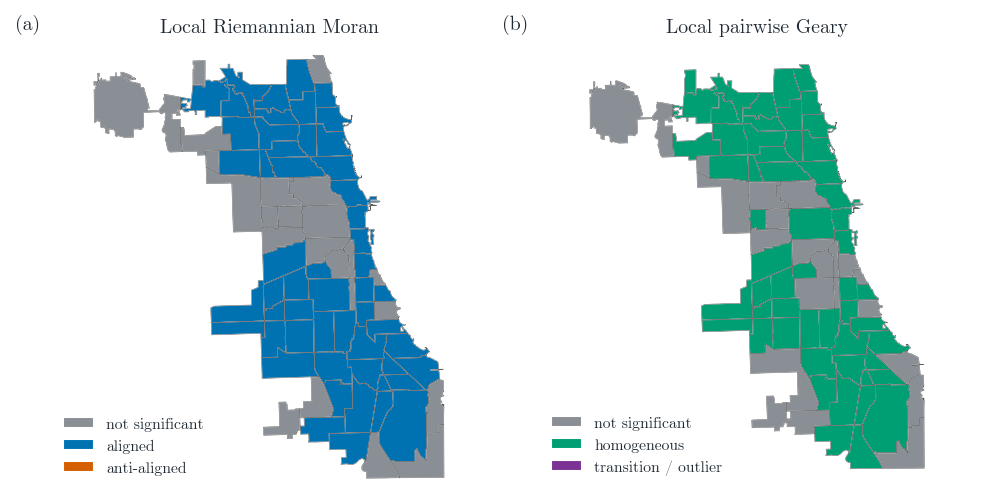

In [6]:
intrinsic = ac.classification_columns(local_results["Intrinsic sphere"])
plot = geography.copy()
for column in intrinsic.columns:
    if column not in plot.columns:
        plot[column] = intrinsic[column].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(ac.TEXT_WIDTH_IN, 3.25), constrained_layout=True)
specifications = [
    ("moran_class", ac.MORAN_COLORS, "Local Riemannian Moran"),
    ("geary_class", ac.GEARY_COLORS, "Local pairwise Geary"),
]
for letter, ax, (column, palette, title) in zip("ab", axes, specifications):
    for label, color in palette.items():
        subset = plot[plot[column] == label]
        if not subset.empty:
            subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.32)
    plot.boundary.plot(ax=ax, color="#5A5A5A", linewidth=0.24)
    ax.set_title(title)
    ax.legend(handles=[Patch(facecolor=color, edgecolor="white", label=label)
                       for label, color in palette.items()], loc="lower left")
    ac.map_axis(ax)
    ac.panel_label(ax, letter)
plt.show()

**Figure 3.** FDR-adjusted intrinsic local results. Panel (a) maps
aligned or anti-aligned tangent departures; panel (b) maps homogeneous
or transition/outlier neighborhoods. Setting `PAPER_SCALE=False` may
change a few FDR-adjusted classifications because the attainable
permutation probabilities are coarser.

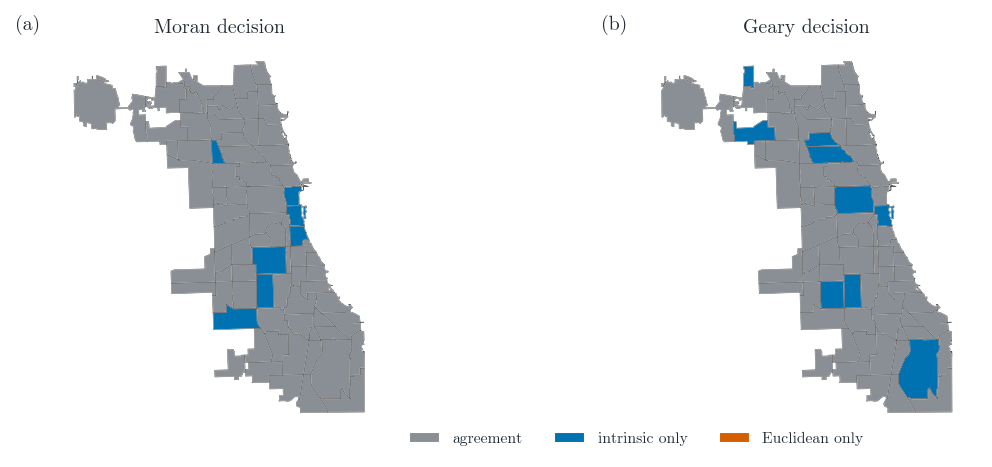

,method,Moran discoveries,Moran Jaccard,Geary discoveries,Geary Jaccard
0,Intrinsic sphere,54,1.000,55,1.000
1,Square-root chordal,56,0.897,56,0.982
2,Raw shares,47,0.870,46,0.836
3,Shannon diversity,16,0.273,7,0.127
4,Standardized shares,55,0.879,53,0.831


In [7]:
raw = local_results["Raw shares"]
difference = geography.copy()
difference["Moran decision"] = "agreement"
difference.loc[intrinsic["I_significant"] & ~raw["I_significant"], "Moran decision"] = "intrinsic only"
difference.loc[~intrinsic["I_significant"] & raw["I_significant"], "Moran decision"] = "Euclidean only"
difference["Geary decision"] = "agreement"
difference.loc[intrinsic["G_significant"] & ~raw["G_significant"], "Geary decision"] = "intrinsic only"
difference.loc[~intrinsic["G_significant"] & raw["G_significant"], "Geary decision"] = "Euclidean only"
decision_colors = {"agreement": ac.MUTED, "intrinsic only": ac.BLUE, "Euclidean only": ac.ORANGE}

fig, axes = plt.subplots(1, 2, figsize=(ac.TEXT_WIDTH_IN, 3.0), constrained_layout=True)
for letter, ax, column in zip("ab", axes, ["Moran decision", "Geary decision"]):
    for label, color in decision_colors.items():
        subset = difference[difference[column] == label]
        if not subset.empty:
            subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.32)
    difference.boundary.plot(ax=ax, color="#5A5A5A", linewidth=0.24)
    ax.set_title(column)
    ac.map_axis(ax)
    ac.panel_label(ax, letter)
axes[1].legend(handles=[Patch(facecolor=color, edgecolor="white", label=label)
                        for label, color in decision_colors.items()],
               loc="lower center", bbox_to_anchor=(0.0, -0.08), ncol=3)
plt.show()

overlap_rows = []
for name, local in local_results.items():
    overlap_rows.append({
        "method": name,
        "Moran discoveries": int(local["I_significant"].sum()),
        "Moran Jaccard": ac.jaccard(local["I_significant"], intrinsic["I_significant"]),
        "Geary discoveries": int(local["G_significant"].sum()),
        "Geary Jaccard": ac.jaccard(local["G_significant"], intrinsic["G_significant"]),
    })
display(pd.DataFrame(overlap_rows).round(3))

**Figure 4.** Community areas where the intrinsic spherical and
raw-share Euclidean local decisions differ. The table reports fresh-run
discovery counts and Jaccard overlap with the intrinsic analysis.

In [8]:
centroids = geography.geometry.centroid
coordinates = np.column_stack([centroids.x.to_numpy(), centroids.y.to_numpy()])
design = np.column_stack([np.ones(len(geography)), coordinates])
design[:, 1:] = (design[:, 1:] - design[:, 1:].mean(axis=0)) / design[:, 1:].std(axis=0)
beta = np.linalg.lstsq(design, sphere_log, rcond=None)[0]
residuals = sphere_log - design @ beta
residual_d2 = ac.pairwise_sqeuclidean(residuals)
trend = ac.global_randomization(
    residuals, residual_d2, W, V_mu=float(np.sum(residuals * residuals)),
    permutations=global_permutations, seed=SEED + 950,
)
W6 = ac.sym_knn(coordinates, k=6)
nearest = ac.global_randomization(
    sphere_log, sphere_d2, W6, V_mu=sphere_v,
    permutations=global_permutations, seed=SEED + 951,
)
sensitivity = pd.DataFrame([
    {"analysis": "Queen contiguity", **global_rows[0]},
    {"analysis": "Symmetric 6-nearest neighbors", **nearest.__dict__},
    {"analysis": "Linear-coordinate tangent residuals", **trend.__dict__},
])
display(sensitivity[["analysis", "I", "C_F", "C_P", "C_T", "p_I_upper", "p_CP_lower"]].round(4))

archived = pd.DataFrame(paper["chicago_compositions"]["global_comparison"])
archived = archived.iloc[:5][["method", "I", "C_P", "local_moran_discoveries", "local_geary_discoveries"]]
display(archived.rename(columns={"method": "archived manuscript method"}).round(4))

,analysis,I,C_F,C_P,C_T,p_I_upper,p_CP_lower
0,Queen contiguity,0.7074,0.2943,0.3017,0.3074,0.0005,0.0005
1,Symmetric 6-nearest neighbors,0.6218,0.3660,0.3753,0.3812,0.0005,0.0005
2,Linear-coordinate tangent residuals,0.4736,0.4665,0.4665,0.4665,0.0005,0.0005


,archived manuscript method,I,C_P,local_moran_discoveries,local_geary_discoveries
0,intrinsic sphere,0.7074,0.3017,54.0,55.0
1,sqrt-chordal Euclidean,0.6990,0.3145,56.0,56.0
2,raw-share Euclidean,0.6976,0.3202,47.0,46.0
3,Shannon diversity,0.4607,0.5327,16.0,7.0
4,standardized multivariate Local Geary,0.5772,0.4312,55.0,53.0
